## 1) Install Required Packages

Install the libraries needed for data loading, preprocessing, modeling, evaluation, and explainability

In [93]:
!pip -q install numpy pandas scikit-learn matplotlib seaborn statsbombpy mplsoccer shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2) Import Libraries

Import all dependencies used in the xG pipeline including StatsBomb data access, modeling utilities, metrics, plotting, and SHAP

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsbombpy import sb
from mplsoccer import Pitch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, brier_score_loss
import shap
import warnings
warnings.filterwarnings('ignore')

ASSETS_DIR = Path('assets/images')
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 3) Load Match Event Data

Load FIFA World Cup 2022 and UEFA Euro 2024 from StatsBomb, merge match events, and keep only shot events for xG modeling

In [95]:
# Load all available competitions from StatsBomb open data
competitions = sb.competitions()

# FIFA World Cup 2022 and UEFA euro 2024
tournaments = [(43, 106), (55, 282)]

all_matches = []
for competition_id, season_id in tournaments:
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    all_matches.append(matches)

matches = pd.concat(all_matches, ignore_index=True)
match_ids = matches['match_id'].drop_duplicates().tolist()

events_list = []
for match_id in match_ids:
    match_events = sb.events(match_id=match_id, split=False, flatten_attrs=True)
    match_events['match_id'] = match_id
    events_list.append(match_events)

# Concatenate match-level event tables into one event dataset
events = pd.concat(events_list, ignore_index=True)

# Keep only shot events these are the observations used for xG modeling
shots = events[events['type'] == 'Shot'].copy()

## 4) Prepare Features and Target

Create shot geometry features, clean contextual fields with Unknown for missing values, and build the binary goal target where 1 means Goal and 0 means No Goal

In [96]:
# Split StatsBomb shot location arrays into explicit x and y coordinates
shots['x'] = shots['location'].apply(lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) >= 2 else np.nan)
shots['y'] = shots['location'].apply(lambda v: v[1] if isinstance(v, (list, tuple)) and len(v) >= 2 else np.nan)

# Define standard StatsBomb pitch and goal geometry for shot feature math
goal_x = 120.0
goal_y = 40.0
goal_width = 8.0
left_post_y = goal_y - goal_width / 2
right_post_y = goal_y + goal_width / 2

# Compute Euclidean distance from shot location to center of goal
shots['shot_distance'] = np.sqrt((goal_x - shots['x']) ** 2 + (goal_y - shots['y']) ** 2)

# Compute visible shooting angle using vectors to left and right goalposts
left_angle = np.arctan2(left_post_y - shots['y'], goal_x - shots['x'])
right_angle = np.arctan2(right_post_y - shots['y'], goal_x - shots['x'])
shots['shot_angle'] = np.abs(right_angle - left_angle)
shots.loc[shots['shot_angle'] > np.pi, 'shot_angle'] = 2 * np.pi - shots.loc[shots['shot_angle'] > np.pi, 'shot_angle']

# Extract categorical and contextual shot features from event payload fields
shots['body_part'] = shots['shot_body_part'].fillna('Unknown').astype(str)
shots['play_pattern'] = shots['play_pattern'].fillna('Unknown').astype(str)
shots['under_pressure'] = shots['under_pressure'].fillna(False).astype(int)

# Create binary target: 1 if outcome is Goal, otherwise 0
shots['is_goal'] = (shots['shot_outcome'].fillna('Unknown').astype(str) == 'Goal').astype(int)

model_data = shots[['x', 'y', 'shot_distance', 'shot_angle', 'under_pressure', 'body_part', 'play_pattern', 'is_goal']].dropna().copy()

## 5) Train and Evaluate the Random Forest xG Model

One hot encode categorical features, train Random Forest, compute xG as predicted goal probability, and evaluate with probabilistic metrics plus ROC and PR curves

,Model,ROC-AUC,Log Loss,Brier Score,PR-AUC
0,Random Forest,0.8514,0.4026,0.1231,0.4856


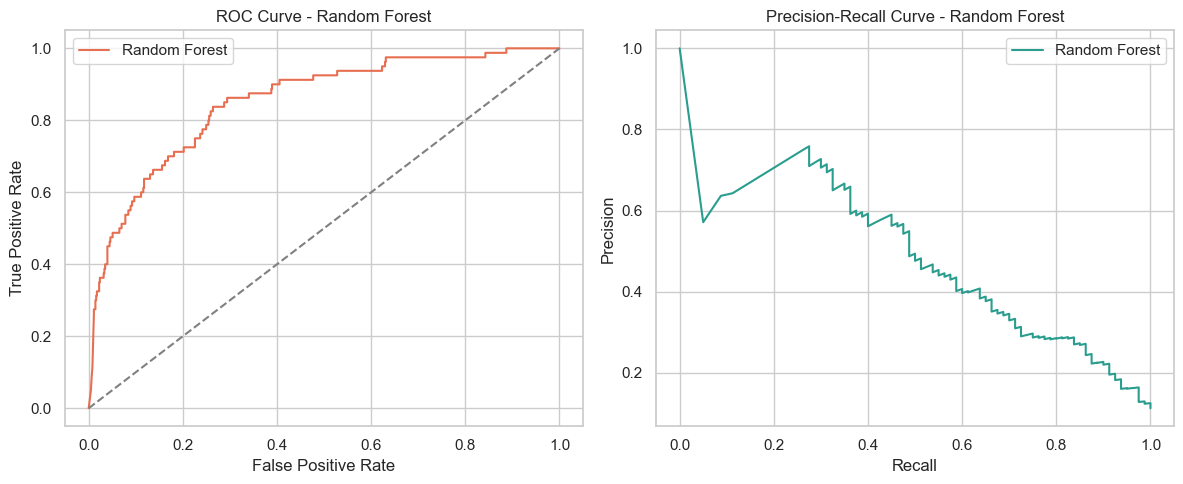

In [97]:
# Select model input features and target
X_raw = model_data[['shot_distance', 'shot_angle', 'under_pressure', 'body_part', 'play_pattern']].copy()
y = model_data['is_goal'].copy()

# One-hot encode categorical columns
X = pd.get_dummies(X_raw, columns=['body_part', 'play_pattern'])

# Split data into train and test sets for unbiased model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Configure Random Forest classifier with class weighting to handle goal/non-goal imbalance
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# xG is modeled as the probability of class 1 (Goal)
rf_xg = rf_model.predict_proba(X_test)[:, 1]

# Summarize probabilistic model quality metrics in a compact table
metrics_df = pd.DataFrame({
    'Model': ['Random Forest'],
    'ROC-AUC': [roc_auc_score(y_test, rf_xg)],
    'Log Loss': [log_loss(y_test, rf_xg, labels=[0, 1])],
    'Brier Score': [brier_score_loss(y_test, rf_xg)],
    'PR-AUC': [average_precision_score(y_test, rf_xg)]
}).round(4)
display(metrics_df)

# Build ROC and Precision-Recall curves to inspect ranking quality and class-imbalance behavior
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_xg)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_xg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_rf, tpr_rf, color='#e76f51', label='Random Forest')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(rec_rf, prec_rf, color='#2a9d8f', label='Random Forest')
axes[1].set_title('Precision-Recall Curve - Random Forest')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
fig.savefig(ASSETS_DIR / 'roc_pr_curves.png', dpi=220, bbox_inches='tight')
plt.show()

## 6) Visualizations and Explainability

Visualize feature influence, map a seeded random sample of 30 shots, and explain a goal shot with predicted xG closest to 0.60 using SHAP

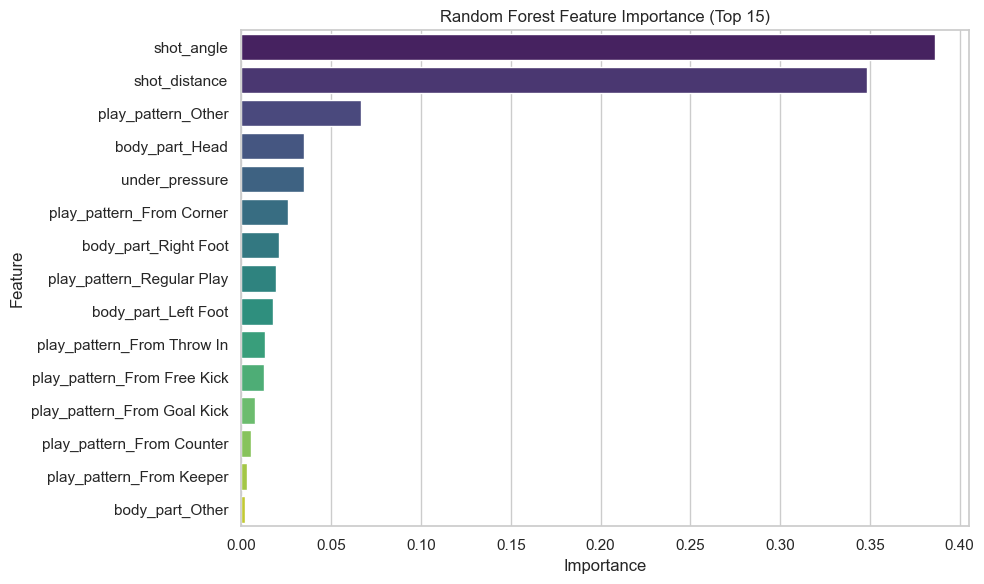

In [98]:
# Rank and visualize the most influential engineered features in the Random Forest model
feature_names = X_train.columns
feature_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.head(15).values, y=feature_importance.head(15).index, palette='viridis')
plt.title('Random Forest Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'feature_importance.png', dpi=220, bbox_inches='tight')
plt.show()

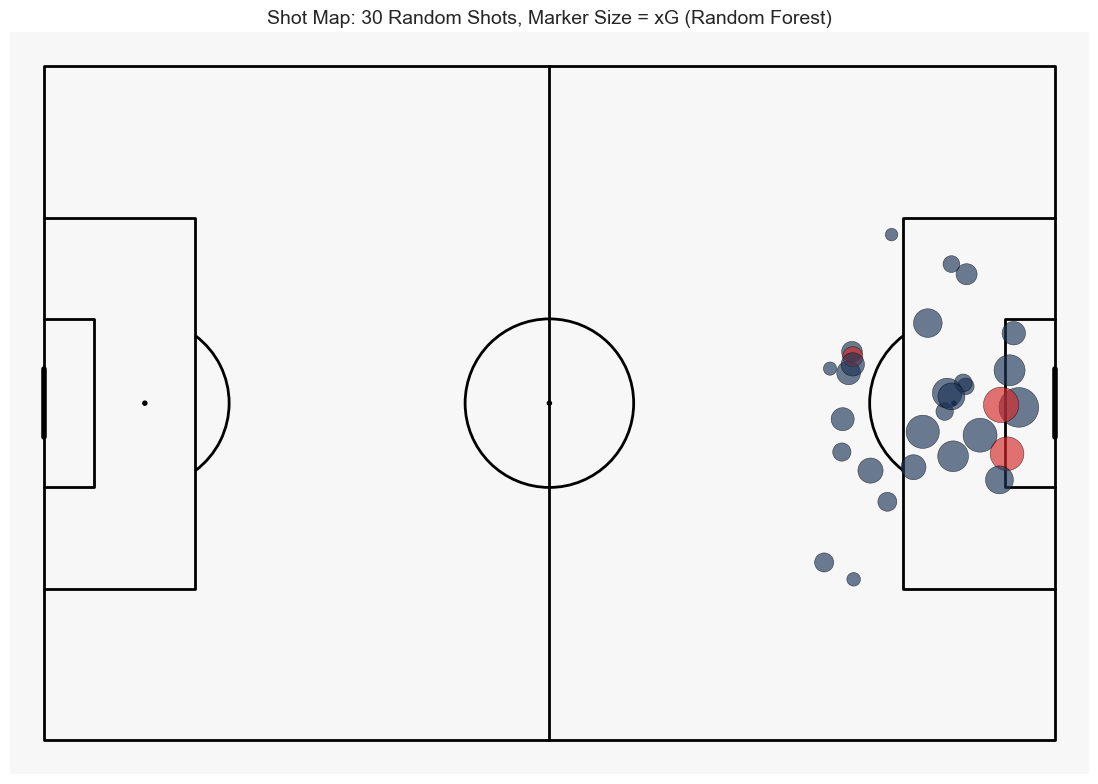

In [99]:
# Build plotting table with location, ground truth, and predicted xG
plot_df = X_test.copy()
plot_df['is_goal'] = y_test.values
plot_df['xg'] = rf_xg
plot_df['x'] = model_data.loc[plot_df.index, 'x']
plot_df['y'] = model_data.loc[plot_df.index, 'y']

# Plot a readable sample instead of all shots
plot_n = min(30, len(plot_df))
plot_df_sample = plot_df.sample(n=plot_n, random_state=42)

# Draw shot map where marker size scales with predicted xG
pitch = Pitch(pitch_type='statsbomb', pitch_color='#f7f7f7', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))
pitch.scatter(
    plot_df_sample['x'],
    plot_df_sample['y'],
    s=30 + 900 * plot_df_sample['xg'],
    c=np.where(plot_df_sample['is_goal'] == 1, '#d62828', '#1d3557'),
    edgecolors='black',
    linewidth=0.4,
    alpha=0.65,
    ax=ax
)
ax.set_title(f'Shot Map: 30 Random Shots, Marker Size = xG (Random Forest)', fontsize=14)
fig.savefig(ASSETS_DIR / 'shot_map_xg.png', dpi=220, bbox_inches='tight')
plt.show()

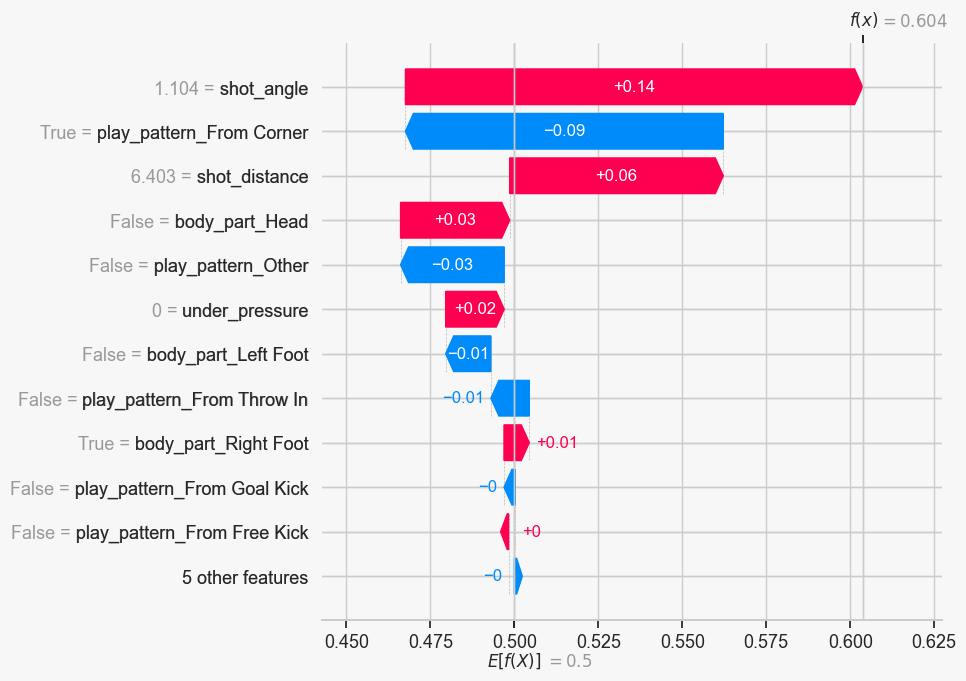

In [103]:
# Explain one goal prediction with xG closest to 0.60 using SHAP waterfall values
feature_names = X_train.columns
target_xg = 0.60
goal_idx = y_test[y_test == 1].index
goal_scores = pd.Series(rf_xg, index=X_test.index).loc[goal_idx]
selected_index = (goal_scores - target_xg).abs().idxmin()
shot_index = int(X_test.index.get_loc(selected_index))

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shot_sv = shap_values[1][shot_index]
    base_value = explainer.expected_value[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shot_sv = shap_values[shot_index, :, 1]
    base_value = explainer.expected_value[1]
else:
    shot_sv = shap_values[shot_index]
    base_value = explainer.expected_value

shot_explanation = shap.Explanation(
    values=shot_sv,
    base_values=base_value,
    data=X_test.iloc[shot_index].values,
    feature_names=feature_names
)
shap.plots.waterfall(shot_explanation, max_display=12, show=False)
fig = plt.gcf()
fig.patch.set_facecolor('#f7f7f7')
for ax in fig.axes:
    ax.set_facecolor('#f7f7f7')
fig.savefig(
    ASSETS_DIR / 'shap_waterfall.png',
    dpi=220,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
    edgecolor='none'
 )
plt.show()